In [58]:
!pip install torch matplotlib scipy

  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [102]:
K=100 #size of the truncated master field
M= 2*K #number of loop equations we are imposing
g=0 #coupling

learning_rate = 0.1
num_epochs = 1000

# loss function : sum of squares of loop equations
def loss(phi_pos, g, M, K):
    phi = torch.cat([-phi_pos, phi_pos])
    t = [torch.sum(phi**n) / K for n in range(0, M+3)]
    residuals = []
    for n in range(2, M+1, 2):
        lhs = t[n] - g * t[n+2]
        rhs = sum(t[k] * t[n-2-k] for k in range(0, n-1))
        scale = (4.0 ** (n/2))  # expected scale of t_n
        r = (lhs - rhs) / scale
        residuals.append(r**2)
    return sum(residuals)

# regularized master field
phi_pos = torch.rand(K//2).double() * 1.0 + 0.5
phi_pos.requires_grad_(True)

optim = torch.optim.Adam([phi_pos], lr=learning_rate)

for epoch in range(num_epochs):
    optim.zero_grad()
    L=loss(phi_pos,g,M,K)
    L.backward()
    optim.step()
    if epoch % 100 == 0:
        print(f"epoch {epoch}, loss {L.item():.6f}")

        
phi = torch.cat([-phi_pos, phi_pos])
print(phi.detach().numpy())

t = [torch.sum(phi**n) / K for n in range(0, M+3)]
print(t[2].item())
print(t[4].item())
print(t[6].item())
    

epoch 0, loss 0.003109
epoch 100, loss 0.000001
epoch 200, loss 0.000001
epoch 300, loss 0.000001
epoch 400, loss 0.000001
epoch 500, loss 0.000001
epoch 600, loss 0.000001
epoch 700, loss 0.000001
epoch 800, loss 0.000001
epoch 900, loss 0.000001
[-0.98626321 -0.35980218 -0.61731342 -1.07066252 -0.05419085 -1.17627914
 -1.43618247 -1.44321674 -1.0233064  -0.72774102 -0.473331   -1.93783391
 -1.1974412  -1.58189502 -1.11678191 -1.71225485 -0.9267334  -0.41241958
 -0.32901896 -1.06607828 -0.34944559 -0.28082284 -0.80534308 -0.27689841
 -0.15412671 -0.49087277 -0.35743957 -0.2459432  -1.20844899 -0.55006247
 -0.50328132 -0.89280713 -0.66914437 -1.06991304 -1.5317847  -0.01360548
 -1.74554342 -1.7468925  -0.54318288 -0.78327287 -1.07660214 -1.74556581
 -1.3699457  -1.24471288 -0.13130813 -0.9141056  -1.42764043  0.0413869
 -0.05716254 -0.4704782   0.98626321  0.35980218  0.61731342  1.07066252
  0.05419085  1.17627914  1.43618247  1.44321674  1.0233064   0.72774102
  0.473331    1.9378339

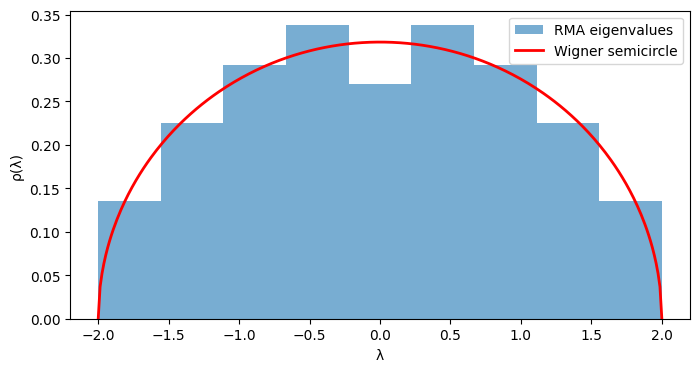

histogram area = 1.000000
semicircle area = 0.999795


In [111]:
phi_vals = np.sort(phi.detach().numpy())
lam = np.linspace(-2, 2, 300)
rho_exact = np.sqrt(np.maximum(4 - lam**2, 0)) / (2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(phi_vals, bins=np.linspace(-2, 2, 10), 
        density=True, alpha=0.6, label='RMA eigenvalues')
ax.plot(lam, rho_exact, 'r-', lw=2, label='Wigner semicircle')
ax.set_xlabel('λ')
ax.set_ylabel('ρ(λ)')
ax.legend()
plt.show()

# sanity check: print the area of the histogram
counts, bin_edges = np.histogram(phi_vals, bins=np.linspace(-2, 2, 11), density=True)
print(f"histogram area = {np.sum(counts * np.diff(bin_edges)):.6f}")  # should be 1.0
print(f"semicircle area = {np.trapezoid(rho_exact, lam):.6f}")           # should be 1.0